In [450]:
import matplotlib.pyplot as plt
import seaborn as sns

In [451]:
import pandas as pd

train_df = pd.read_csv('train.csv')

train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [452]:
train_df.drop(columns=['PassengerId'], inplace=True)

In [453]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [454]:
train_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [455]:
print(train_df['Survived'].sum() / len(train_df['Survived']))

0.3838383838383838


In [456]:
for name, col in train_df.notna().items(): 
    if not col.all(): print(name, col.sum() / len(col))

Age 0.8013468013468014
Cabin 0.22895622895622897
Embarked 0.9977553310886644


In [457]:
for name, col in train_df.items():
    print(name, len(col.unique()))

Survived 2
Pclass 3
Name 891
Sex 2
Age 89
SibSp 7
Parch 7
Ticket 681
Fare 248
Cabin 148
Embarked 4


---

In [458]:
test_df = pd.read_csv('test.csv')
test_df.drop(columns=['PassengerId'], inplace=True)

**Status**

In [459]:
train_df[['Surname', 'Name']] = train_df['Name'].str.split(', ', n=1, expand=True)
train_df[['Status', 'Name']] = train_df['Name'].str.split('. ', n=1, regex=False, expand=True)

test_df[['Surname', 'Name']] = test_df['Name'].str.split(', ', n=1, expand=True)
test_df[['Status', 'Name']] = test_df['Name'].str.split('. ', n=1, regex=False, expand=True)

In [460]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Status
0,0,3,Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr
1,1,1,John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs
2,1,3,Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss
3,1,1,Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs
4,0,3,William Henry,male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr


In [461]:
print(train_df['Status'].unique())
print(len(train_df['Surname'].unique()))

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']
667


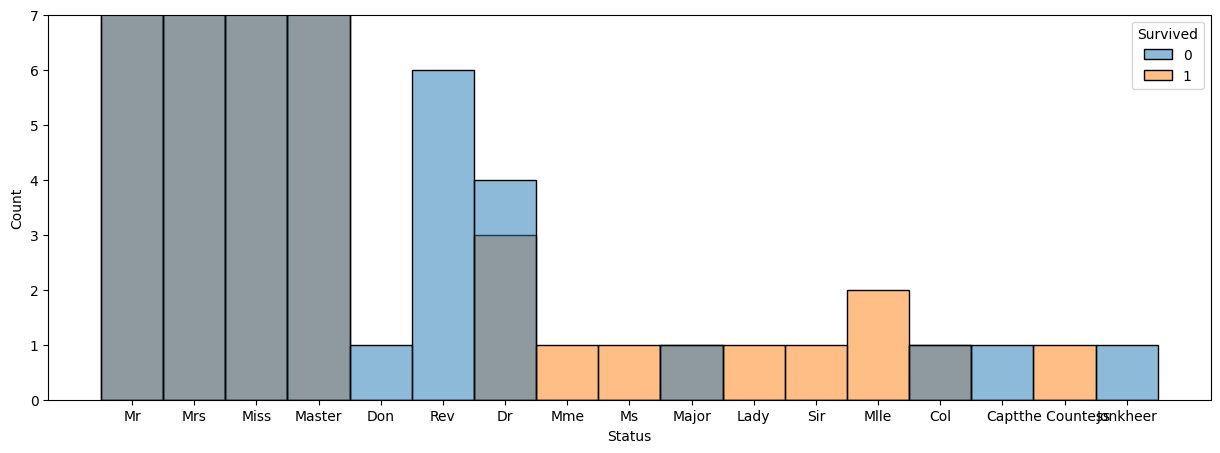

In [462]:
plt.figure(figsize=(15, 5))
sns.histplot(train_df, x='Status', hue='Survived')
plt.ylim(top=7)
plt.show()

In [463]:
st_main_list = ['Mr', 'Mrs', 'Miss', 'Master']
st0_list = ['Don', 'Rev', 'Capt', 'Jonkheer']
st1_list = ['Mme', 'Ms', 'Lady', 'Sir', 'Mlle', 'the Countess']


train_df['Status'] = train_df['Status'].replace({st0: 'st0' for st0 in st0_list} | {st1: 'st1' for st1 in st1_list})
train_df.loc[~train_df['Status'].isin(st_main_list + ['st0', 'st1']), 'Status'] = 'other'

test_df['Status'] = test_df['Status'].replace({st0: 'st0' for st0 in st0_list} | {st1: 'st1' for st1 in st1_list})
test_df.loc[~test_df['Status'].isin(st_main_list + ['st0', 'st1']), 'Status'] = 'other'

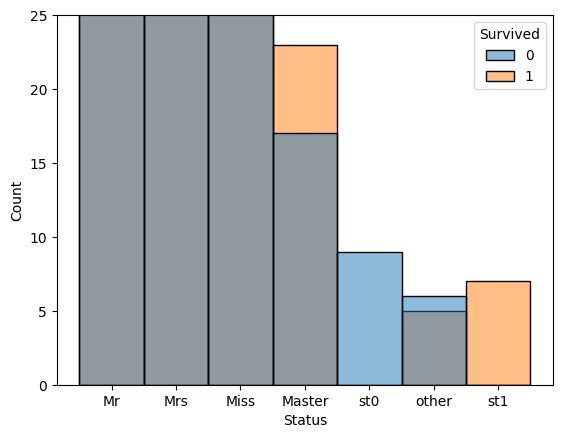

In [464]:
sns.histplot(train_df, x='Status', hue='Survived')
plt.ylim(top=25)
plt.show()

**Fare**

In [465]:
print(train_df['Fare'].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


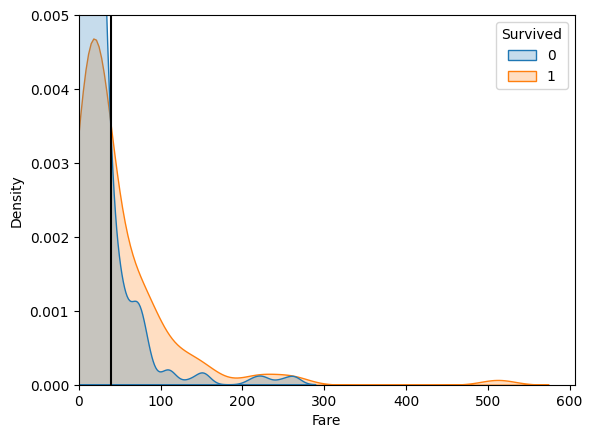

In [466]:
sns.kdeplot(train_df, x='Fare', hue='Survived', fill=True)
plt.ylim(top=0.005)
plt.xlim(left=0)
plt.vlines(40, ymin=0, ymax=1, color='black')

In [467]:
# plt.figure(figsize=(10, 5))
# plt.ylim(top=100)
# plt.vlines(40, ymin=0, ymax=100, color='black')
# sns.histplot(train_df, x='Fare', hue='Survived', kde=True)

In [468]:
# def gini(p0, p1):
#     return 1 - (p0**2 + p1**2)

# t_min = -1
# G_min = float('inf')

# for t in range(int(train_df['Fare'].min()), int(train_df['Fare'].max())):
#     left_df = train_df[train_df['Fare'] <= t]
#     right_df = train_df[train_df['Fare'] > t]

#     G = -1 * ((1-left_df['Survived']).sum() + right_df['Survived'].sum())
#     if G < G_min:
#         G_min = G
#         t_min = t

# print(t_min)


In [469]:
from sklearn.impute import SimpleImputer

fare_imputer = SimpleImputer(strategy='mean')
test_df[['Fare']] = fare_imputer.fit_transform(test_df[['Fare']])

In [470]:
train_df['Fare>40'] = (train_df['Fare'] > 40).astype(int)
test_df['Fare>40'] = (test_df['Fare'] > 40).astype(int)

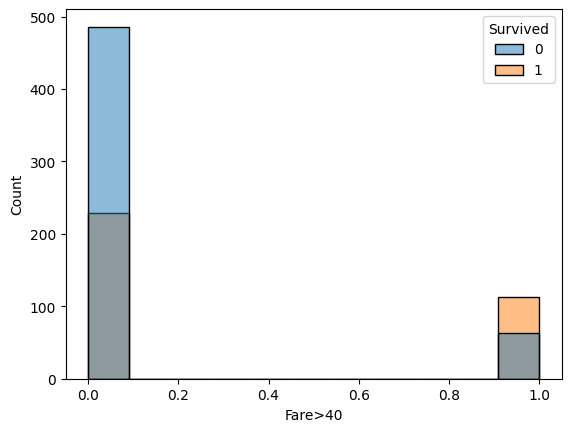

In [471]:
sns.histplot(train_df, x='Fare>40', hue='Survived')
plt.show()

**Sex**

<Axes: xlabel='Sex', ylabel='Count'>

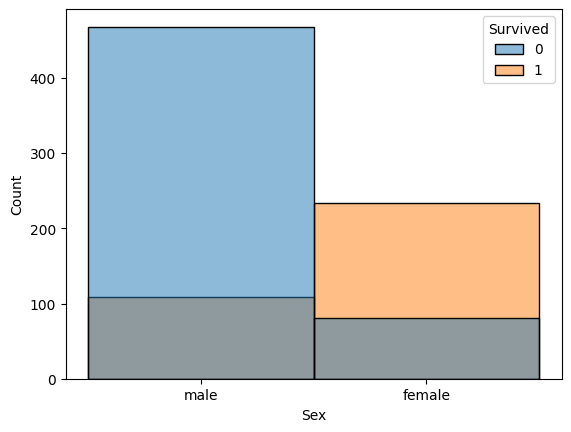

In [472]:
sns.histplot(train_df, x='Sex', hue='Survived')

In [473]:
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df.rename(columns={'Sex': 'IsFemale'}, inplace=True)

test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df.rename(columns={'Sex': 'IsFemale'}, inplace=True)

In [474]:
train_df.head()

,Survived,Pclass,Name,IsFemale,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Status,Fare>40
0,0,3,Owen Harris,0,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0
1,1,1,John Bradley (Florence Briggs Thayer),1,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1
2,1,3,Laina,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0
3,1,1,Jacques Heath (Lily May Peel),1,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1
4,0,3,William Henry,0,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0


**Age**

C:\Users\Konstantin\AppData\Local\Temp\ipykernel_11212\1246369612.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(train_df, x='Age', hue=name, ax=axes[i], fill=True)


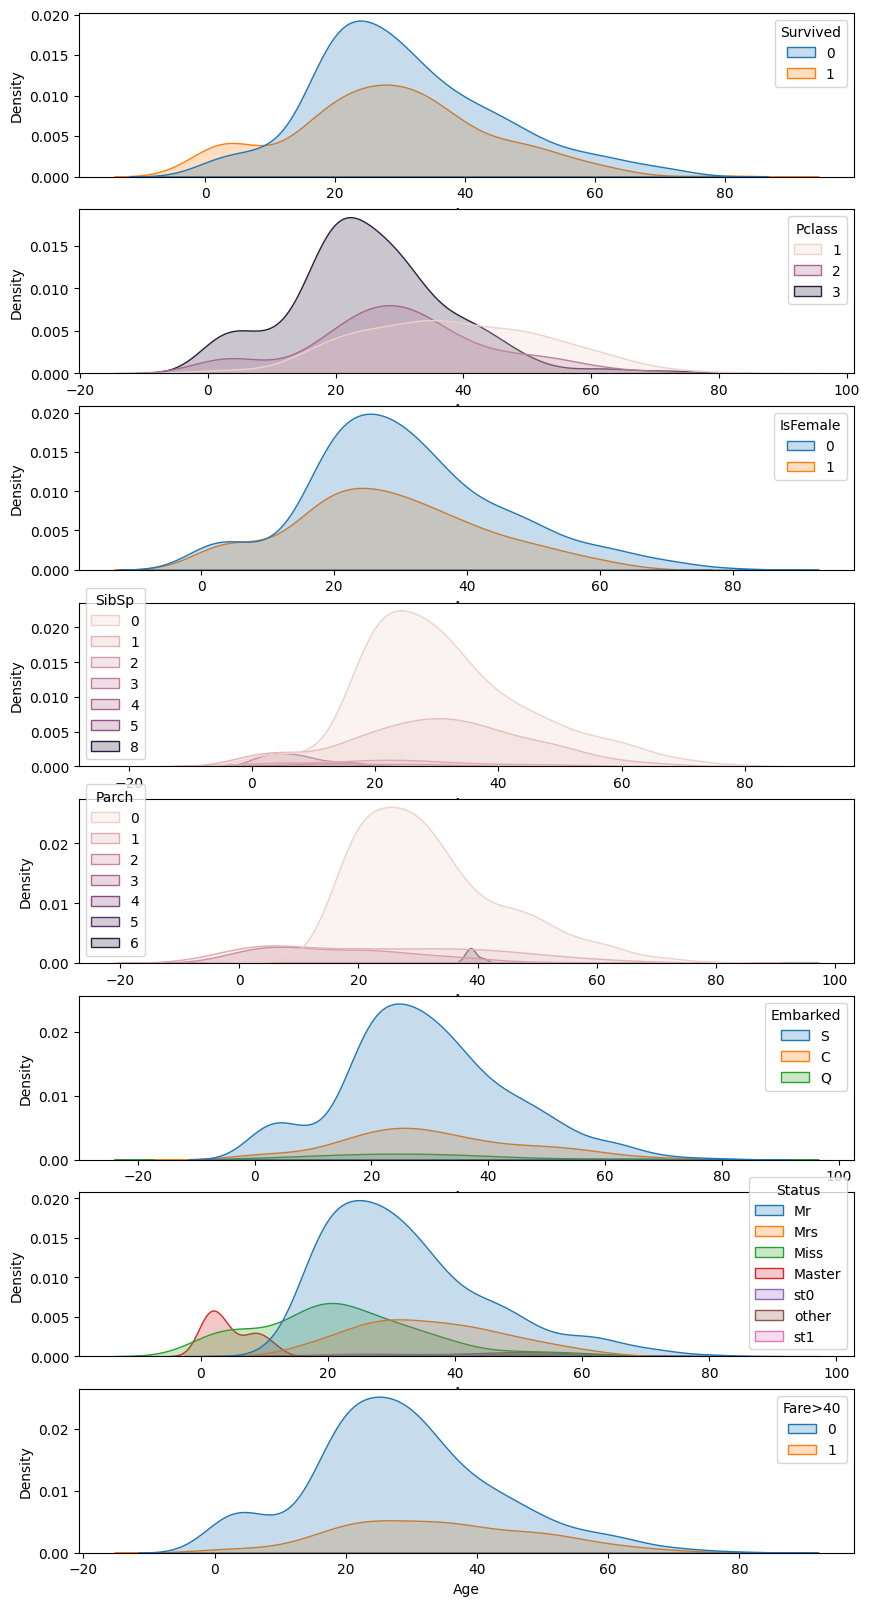

In [475]:
short_columns = [name for name, col in train_df.items() if len(col.unique()) <= 10]

fix, axes = plt.subplots(len(short_columns), 1, figsize=(10, 20))
for i, name in enumerate(short_columns):
    sns.kdeplot(train_df, x='Age', hue=name, ax=axes[i], fill=True)

In [476]:
imp_columns = ['Pclass', 'SibSp', 'Parch', 'Status']

train_df['Age'] = train_df.groupby(imp_columns)['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Age'] = test_df.groupby(imp_columns)['Age'].transform(lambda x: x.fillna(x.median()))

c:\Users\Konstantin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Konstantin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Konstantin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Konstantin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Konstantin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.

In [477]:
print(train_df['Age'].count() / len(train_df['Age']))

0.9910213243546577


In [478]:
train_df.loc[train_df['Age'].isna(), 'Age'] = train_df['Age'].median()
test_df.loc[test_df['Age'].isna(), 'Age'] = train_df['Age'].median()

(0.003, 0.004)

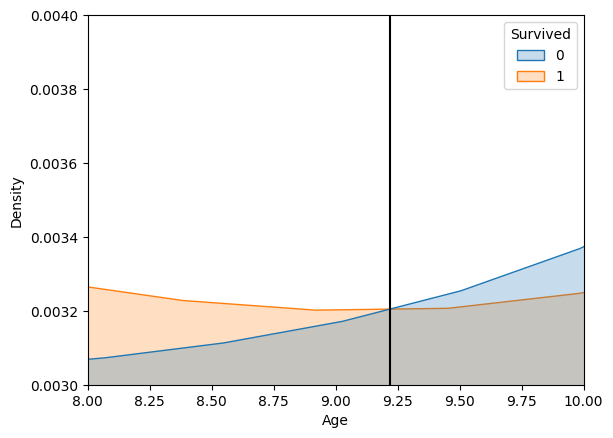

In [479]:
sns.kdeplot(train_df, x='Age', hue='Survived', fill=True)
plt.vlines(9.22, ymin=0, ymax=0.02, color='black')
plt.xlim(8, 10)
plt.ylim(bottom=0.003, top=0.004)

In [480]:
train_df['Age<9.22'] = (train_df['Age'] < 9.22).astype(int)
test_df['Age<9.22'] = (test_df['Age'] < 9.22).astype(int)

In [481]:
train_df.head()

,Survived,Pclass,Name,IsFemale,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Status,Fare>40,Age<9.22
0,0,3,Owen Harris,0,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0,0
1,1,1,John Bradley (Florence Briggs Thayer),1,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,0
2,1,3,Laina,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0,0
3,1,1,Jacques Heath (Lily May Peel),1,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1,0
4,0,3,William Henry,0,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0,0


**Embarded**

In [482]:
print(train_df['Embarked'].unique())

['S' 'C' 'Q' nan]


<Axes: xlabel='Embarked', ylabel='Count'>

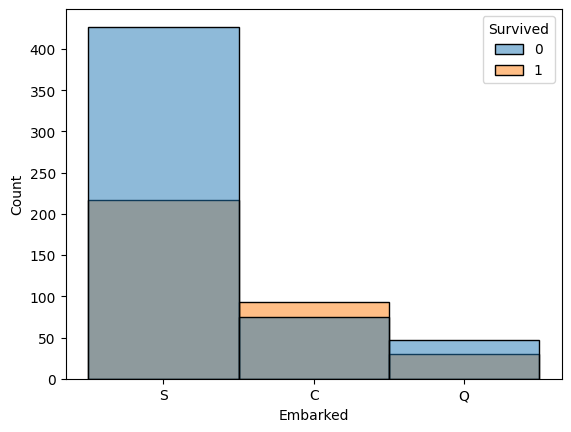

In [483]:
sns.histplot(train_df, x='Embarked', hue='Survived')

In [484]:
from sklearn.impute import SimpleImputer

embakded_imputer = SimpleImputer(strategy='most_frequent')
train_df[['Embarked']] = embakded_imputer.fit_transform(train_df[['Embarked']])

In [485]:
train_df.head()

,Survived,Pclass,Name,IsFemale,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Status,Fare>40,Age<9.22
0,0,3,Owen Harris,0,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0,0
1,1,1,John Bradley (Florence Briggs Thayer),1,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,0
2,1,3,Laina,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0,0
3,1,1,Jacques Heath (Lily May Peel),1,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1,0
4,0,3,William Henry,0,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0,0


**Ticket**

In [486]:
train_df['Dataset'] = 'train'
test_df['Dataset'] = 'test'
df = pd.concat([train_df, test_df], ignore_index=True)

In [487]:
df[['TPrefix', 'TNumber']] = df['Ticket'].str.rsplit(' ', n=1, expand=True)

mask = df['TNumber'].isna()

df.loc[mask, 'TNumber'] = df.loc[mask, 'TPrefix']
df.loc[mask, 'TPrefix'] = 'No'

df.loc[(df['TNumber'] == 'LINE'), 'TPrefix'] = 'LINE'
df['TNumber'] = df['TNumber'].replace({'LINE': '0'}).astype(int)

array(['A/5', 'PC', 'STON/O2.', 'No', 'PP', 'A/5.', 'C.A.', 'A./5.',  
       'SC/Paris', 'S.C./A.4.', 'A/4.', 'CA', 'S.P.', 'S.O.C.', 'SO/C',  
       'W./C.', 'SOTON/OQ', 'W.E.P.', 'STON/O 2.', 'A4.', 'C',  
       'SOTON/O.Q.', 'SC/PARIS', 'S.O.P.', 'A.5.', 'Fa', 'CA.', 'LINE',  
       'F.C.C.', 'W/C', 'SW/PP', 'SCO/W', 'P/PP', 'SC', 'SC/AH', 'A/S',  
       'SC/AH Basle', 'A/4', 'WE/P', 'S.W./PP', 'S.O./P.P.', 'F.C.',  
       'SOTON/O2', 'S.C./PARIS', 'C.A./SOTON'], dtype=object)  

In [488]:
df['TPrefix'].unique()

array(['A/5', 'PC', 'STON/O2.', 'No', 'PP', 'A/5.', 'C.A.', 'A./5.',
       'SC/Paris', 'S.C./A.4.', 'A/4.', 'CA', 'S.P.', 'S.O.C.', 'SO/C',
       'W./C.', 'SOTON/OQ', 'W.E.P.', 'STON/O 2.', 'A4.', 'C',
       'SOTON/O.Q.', 'SC/PARIS', 'S.O.P.', 'A.5.', 'Fa', 'CA.', 'LINE',
       'F.C.C.', 'W/C', 'SW/PP', 'SCO/W', 'P/PP', 'SC', 'SC/AH', 'A/S',
       'SC/AH Basle', 'A/4', 'WE/P', 'S.W./PP', 'S.O./P.P.', 'F.C.',
       'SOTON/O2', 'S.C./PARIS', 'C.A./SOTON', 'SC/A.3', 'STON/OQ.',
       'SC/A4', 'AQ/4', 'A. 2.', 'LP', 'AQ/3.'], dtype=object)

In [489]:
df['TPrefix'] = df['TPrefix'].replace({
    'A/5.': 'A/5',
    'A./5.': 'A/5',
    'A.5.': 'A/5',

    'STON/O2.': 'SOTON/O2',
    'STON/O 2.': 'SOTON/O2',

    'C.A.': 'CA',
    'CA.': 'CA',

    'SC/Paris': 'SC/PARIS',
    'S.C./PARIS': 'SC/PARIS',

    'A/4.': 'A/4',
    'A4.': 'A/4',

    'S.W./PP': 'SW/PP',

    'S.C./A.4.': 'SC/A4'
})

In [490]:
counts = df['TPrefix'].value_counts()
df.loc[df['TPrefix'].isin(counts[counts < 20].index), 'TPrefix'] = 'other'

In [491]:
train_df = df[df['Dataset'] == 'train'].copy()
test_df = df[df['Dataset'] == 'test'].copy()

train_df.drop(columns=['Dataset'], inplace=True)
test_df.drop(columns=['Dataset', 'Survived'], inplace=True)

train_df['Survived'] = train_df['Survived'].astype(int)

<Axes: xlabel='TPrefix', ylabel='Count'>

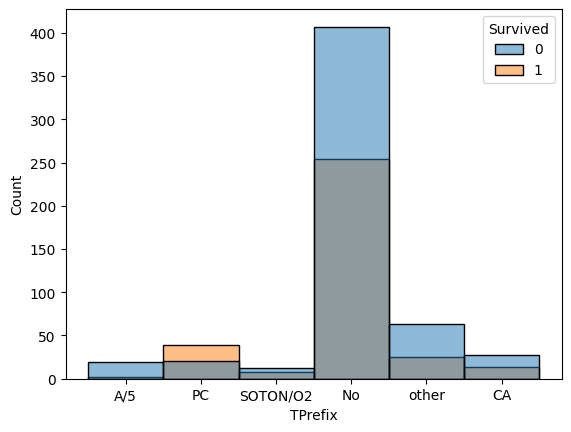

In [492]:
sns.histplot(train_df, x='TPrefix', hue='Survived')

<Axes: xlabel='TNumber', ylabel='Density'>

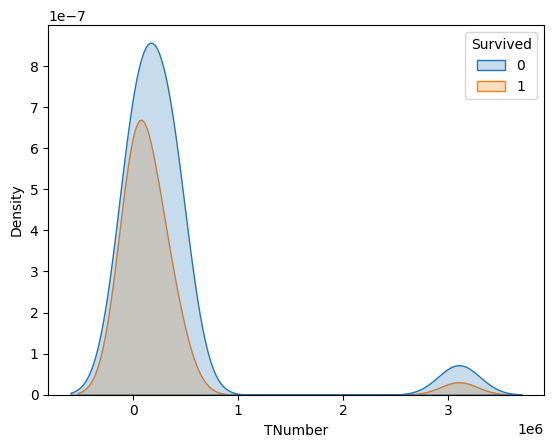

In [493]:
sns.kdeplot(train_df, x='TNumber', hue='Survived', fill=True)

**Drop columns**

In [494]:
train_df.head()

,Survived,Pclass,Name,IsFemale,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Status,Fare>40,Age<9.22,TPrefix,TNumber
0,0,3,Owen Harris,0,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0,0,A/5,21171
1,1,1,John Bradley (Florence Briggs Thayer),1,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,0,PC,17599
2,1,3,Laina,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0,0,SOTON/O2,3101282
3,1,1,Jacques Heath (Lily May Peel),1,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1,0,No,113803
4,0,3,William Henry,0,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0,0,No,373450


In [495]:
train_df.drop(columns=['Name', 'Ticket', 'Cabin', 'Surname', 'TNumber'], inplace=True)
test_df.drop(columns=['Name', 'Ticket', 'Cabin', 'Surname', 'TNumber'], inplace=True)

In [496]:
train_df.head()

,Survived,Pclass,IsFemale,Age,SibSp,Parch,Fare,Embarked,Status,Fare>40,Age<9.22,TPrefix
0,0,3,0,22.0,1,0,7.2500,S,Mr,0,0,A/5
1,1,1,1,38.0,1,0,71.2833,C,Mrs,1,0,PC
2,1,3,1,26.0,0,0,7.9250,S,Miss,0,0,SOTON/O2
3,1,1,1,35.0,1,0,53.1000,S,Mrs,1,0,No
4,0,3,0,35.0,0,0,8.0500,S,Mr,0,0,No


In [497]:
test_df.head()

,Pclass,IsFemale,Age,SibSp,Parch,Fare,Embarked,Status,Fare>40,Age<9.22,TPrefix
891,3,0,34.5,0,0,7.8292,Q,Mr,0,0,No
892,3,1,47.0,1,0,7.0000,S,Mrs,0,0,No
893,2,0,62.0,0,0,9.6875,Q,Mr,0,0,No
894,3,0,27.0,0,0,8.6625,S,Mr,0,0,No
895,3,1,22.0,1,1,12.2875,S,Mrs,0,0,No


In [498]:
print(train_df.isna().any().any())
print(test_df.isna().any().any())

False
False


---

In [499]:
X = train_df.copy()
y = train_df['Survived'].copy()
X.drop(columns=['Survived'], inplace=True)

In [500]:
from catboost import CatBoostClassifier

cat_features = train_df.select_dtypes('object').columns.to_list()
model = CatBoostClassifier(random_state=42, verbose=False, cat_features=cat_features)

In [501]:
# from sklearn.model_selection import GridSearchCV

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid={
#         'learning_rate': [0.05, 0.01, 0.15, 0.3],
#         'max_depth': [4, 6, 8, 10],
#         'n_estimators': [50, 100, 150, 200]
#     },
#     scoring='accuracy'
# )

# grid_search.fit(X, y)

# print(grid_search.best_params_)
# print(grid_search.best_score_)

In [502]:
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid={
#         'learning_rate': [0.3, 0.5, 0.7],
#         'max_depth': [4, 6, 8, 10],
#         'n_estimators': [100, 150, 200]
#     },
#     scoring='accuracy'
# )

# grid_search.fit(X, y)

# print(grid_search.best_params_)
# print(grid_search.best_score_)

In [506]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model,
    param_grid={
        'learning_rate': [0.3],
        'max_depth': [6],
        'n_estimators': [150]
    },
    scoring='accuracy'
)

grid_search.fit(X, y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 150}
0.8350134957002073


In [503]:
model = CatBoostClassifier(random_state=42, verbose=False, cat_features=cat_features,
                           learning_rate=0.3, max_depth=6, n_estimators=150)

model.fit(X, y)

---

In [504]:
X_test = test_df.copy()
y_test = model.predict(X_test)

In [505]:
sub = pd.read_csv('gender_submission.csv')
sub['Survived'] = y_test
sub.to_csv('submission.csv', index=False)